In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

df = pd.read_csv('data/raw/listings.csv')

In [49]:
#Dropping records with nulls in price column
df = df.dropna(subset = ['price'])
print(f'{df.shape[0]:,} listings × {df.shape[1]} features')

61,963 listings × 79 features


In [50]:
df['price'].unique()

array(['$70.00', '$149.00', '$411.00', ..., '$10,028.00', '$10,020.00',
       '$3,509.00'], shape=(1350,), dtype=object)

In [51]:
# Cleaning price column
df['price'] = df['price'].replace('[\$,]', '', regex=True).astype(float)
print(f'Price range: ${df.price.min():.0f} - ${df.price.max():,.0f}')
print(f'Median: ${df.price.median():.0f}')

Price range: $7 - $1,085,147
Median: $135


### Price Analysis

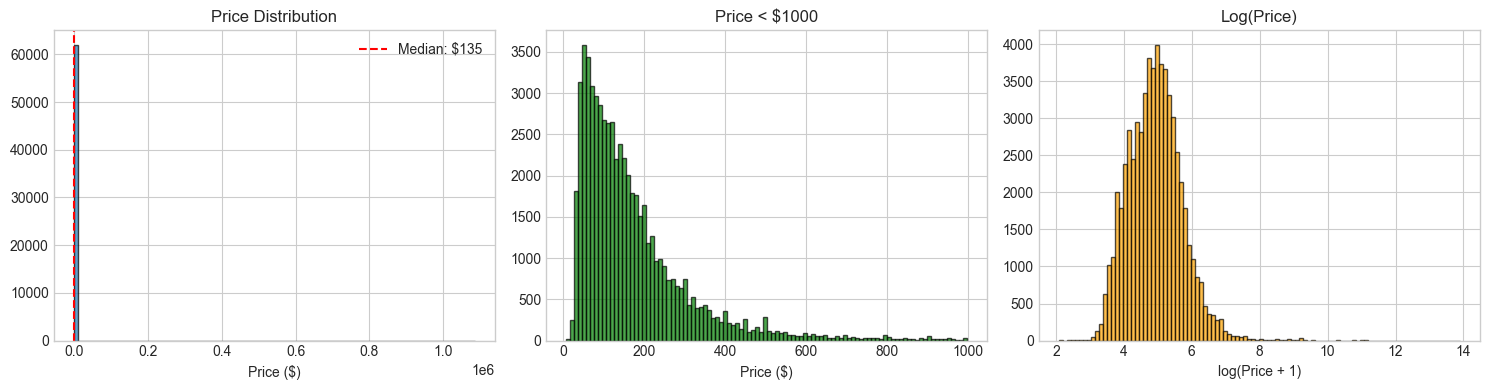

In [52]:
# Price distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['price'], bins=100, edgecolor='black', alpha=0.7)
axes[0].axvline(df.price.median(), color='red', linestyle='--', label=f'Median: ${df.price.median():.0f}')
axes[0].set(title='Price Distribution', xlabel='Price ($)')
axes[0].legend()

axes[1].hist(df[df.price < 1000]['price'], bins=100, edgecolor='black', alpha=0.7, color='green')
axes[1].set(title='Price < $1000', xlabel='Price ($)')

axes[2].hist(np.log1p(df['price']), bins=100, edgecolor='black', alpha=0.7, color='orange')
axes[2].set(title='Log(Price)', xlabel='log(Price + 1)')

plt.tight_layout()
plt.show()

### Property and Room Types Analysis

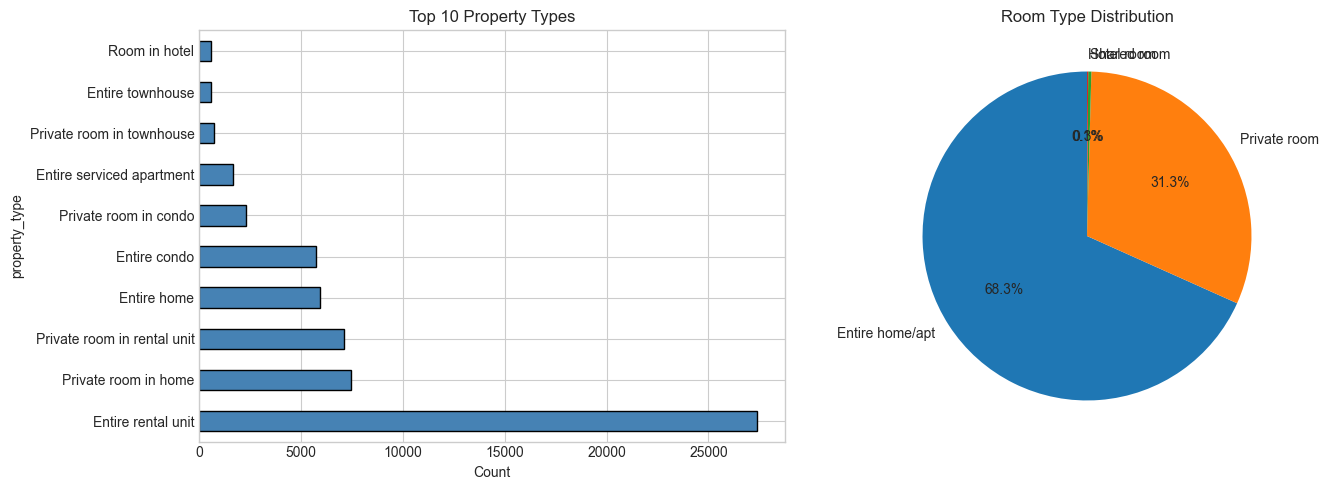

Median Price by Room Type:
room_type
Hotel room         281.0
Entire home/apt    175.0
Private room        61.0
Shared room         32.0
Name: price, dtype: float64


In [53]:
# Property and room types
if 'property_type' in df.columns and 'room_type' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    df['property_type'].value_counts().head(10).plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='black')
    axes[0].set(title='Top 10 Property Types', xlabel='Count')
    
    df['room_type'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90)
    axes[1].set(title='Room Type Distribution', ylabel='')
    
    plt.tight_layout()
    plt.show()
    
    print('Median Price by Room Type:')
    print(df.groupby('room_type')['price'].median().sort_values(ascending=False))

### Missing Data Analysis

In [54]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing': missing, 'Pct': missing_pct})
missing_df = missing_df[missing_df.Missing > 0].sort_values('Pct', ascending=False)

print(f'Columns with missing: {len(missing_df)}/{len(df.columns)}')
print(f'\nTop 20:')
print(missing_df.head(20))

high = missing_df[missing_df.Pct > 30]
medium = missing_df[(missing_df.Pct > 10) & (missing_df.Pct <= 30)]
low = missing_df[missing_df.Pct <= 10]

print(f'\nHigh (>30%): {len(high)}, Medium (>10 and <=30): {len(medium)}, Low (<=10): {len(low)}')

Columns with missing: 38/79

Top 20:
                              Missing         Pct
neighbourhood_group_cleansed    61963  100.000000
license                         61963  100.000000
calendar_updated                61963  100.000000
neighborhood_overview           37446   60.432839
neighbourhood                   37445   60.431225
host_neighbourhood              35407   57.142165
host_about                      29028   46.847312
host_location                   17412   28.100641
review_scores_location          13912   22.452109
review_scores_value             13912   22.452109
review_scores_checkin           13912   22.452109
review_scores_communication     13911   22.450495
review_scores_cleanliness       13911   22.450495
review_scores_accuracy          13911   22.450495
review_scores_rating            13908   22.445653
last_review                     13908   22.445653
first_review                    13908   22.445653
reviews_per_month               13908   22.445653
host_response

In [55]:
# Dropping columns with 100% missing values

df.drop(columns = ['neighbourhood_group_cleansed','license','calendar_updated'], inplace = True)

print("Dropped columns with 100% missing values.")
print("Keeping columns with <100% missing values as they might have important insights while segmentation.")
print(f"Updated data: {df.shape[0]} records x {df.shape[1]} features")

Dropped columns with 100% missing values.
Keeping columns with <100% missing values as they might have important insights while segmentation.
Updated data: 61963 records x 76 features


### Anomaly Detection Using Isolation Forest

In [56]:
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
exclude_cols = ['id', 'host_id', 'scrape_id']
numeric_features = [col for col in numeric_features if col not in exclude_cols]

print(f'Total Numeric features: {len(numeric_features)}')

# Creating missing indicators before imputation

X_anomaly = pd.DataFrame()

imp_features_for_missing_indicators = [
    'price', 'bedrooms', 'bathrooms', 'beds',
    'review_scores_rating', 'review_scores_accuracy',
    'review_scores_cleanliness', 'review_scores_location',
    'host_response_rate', 'host_acceptance_rate',
    'neighbourhood','host_neighbourhood'
]

missing_count = 0
for feat in imp_features_for_missing_indicators:
    if feat in df.columns:
        X_anomaly[f'{feat}_missing'] = df[feat].isnull().astype(int)
        missing_count += 1

# Add total missing count per row
X_anomaly['total_missing_count'] = df[numeric_features].isnull().sum(axis=1)
X_anomaly['missing_percentage'] = (df[numeric_features].isnull().sum(axis=1) / 
                                   len(numeric_features)) * 100

print(f'Created {missing_count} missing indicators')
print(f'Added total_missing_count and missing_percentage')

# Adding numeric features (with minimal imputation)

for col in numeric_features:
    # Copying original values
    X_anomaly[col] = df[col].copy()
    
    # Filling only what's necessary
    median_val = X_anomaly[col].median()
    if pd.isna(median_val):
        X_anomaly[col] = X_anomaly[col].fillna(0)
    else:
        X_anomaly[col] = X_anomaly[col].fillna(median_val)

# Encoding categorical features

categorical_features = df.select_dtypes(include=['object', 'category']).columns.tolist()
encoded_count = 0

for cat_feature in categorical_features:
    n_unique = df[cat_feature].nunique()
    
    if n_unique < 100:
        le = LabelEncoder()
        try:
            X_anomaly[f'{cat_feature}_encoded'] = le.fit_transform(
                df[cat_feature].fillna('Unknown').astype(str)
            )
            encoded_count += 1
        except Exception as e:
            print(f'Skipped {cat_feature}: {e}')

print(f'Encoded {encoded_count} categorical features')

print(f'\nFinal feature matrix:')
print(f'Total features: {X_anomaly.shape[1]}')
print(f'- Missing indicators: {missing_count + 2}')
print(f'- Numeric features: {len(numeric_features)}')
print(f'- Encoded categorical: {encoded_count}')
print(f'Total rows: {X_anomaly.shape[0]:,}')

# Verifying no nulls
remaining_nans = X_anomaly.isnull().sum().sum()
if remaining_nans > 0:
    print(f'\nFilling {remaining_nans} remaining NaN values with 0')
    X_anomaly = X_anomaly.fillna(0)

print(f'\nData ready for anomaly detection')

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_anomaly)

# Training Isolation Forest
iso_forest = IsolationForest(
    contamination=0.05,
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    verbose=0
)

df['is_anomaly'] = iso_forest.fit_predict(X_scaled)
df['anomaly_score'] = iso_forest.score_samples(X_scaled)

n_anomalies = (df.is_anomaly == -1).sum()
pct_anomalies = n_anomalies / len(df) * 100

Total Numeric features: 40
Created 12 missing indicators
Added total_missing_count and missing_percentage
Encoded 16 categorical features

Final feature matrix:
Total features: 70
- Missing indicators: 14
- Numeric features: 40
- Encoded categorical: 16
Total rows: 61,963

Data ready for anomaly detection


### Analysing results of Anomaly Detection

In [57]:
print(f'Detected: {n_anomalies:,} anomalies ({pct_anomalies:.2f}%)')
print(f'Normal: {(df.is_anomaly == 1).sum():,} listings')

anomalies = df[df.is_anomaly == -1]
normal = df[df.is_anomaly == 1]

# Checking missing data patterns
print('\nMissing data comparison:')
normal_missing_avg = normal[numeric_features].isnull().sum(axis=1).mean()
anomaly_missing_avg = anomalies[numeric_features].isnull().sum(axis=1).mean()

print(f'Normal listings:   {normal_missing_avg:.1f} avg missing features')
print(f'Anomaly listings:  {anomaly_missing_avg:.1f} avg missing features')

if anomaly_missing_avg > normal_missing_avg * 1.5:
    print(f'Anomalies have 50%+ more missing data')

# Feature comparison
comparison_features = ['price', 'bedrooms', 'bathrooms', 'number_of_reviews',
                      'minimum_nights', 'maximum_nights', 'availability_365']
comparison_features = [f for f in comparison_features if f in df.columns]

print('\nFeature comparison (median):')
for feat in comparison_features:
    normal_val = normal[feat].median()
    anomaly_val = anomalies[feat].median()
    diff_pct = ((anomaly_val - normal_val) / normal_val * 100) if normal_val != 0 else 0
    print(f'{feat:<25} Normal: {normal_val:>8.1f}  |  Anomaly: {anomaly_val:>8.1f}  ({diff_pct:+.0f}%)')

# Showing examples
print('\nMost extreme anomalies:')
example_cols = ['price', 'bedrooms', 'bathrooms', 'minimum_nights',
               'number_of_reviews', 'availability_365', 'anomaly_score']
example_cols = [c for c in example_cols if c in df.columns]

extreme = anomalies.nsmallest(5, 'anomaly_score')[example_cols]
print(extreme.to_string(index=False))

Detected: 3,099 anomalies (5.00%)
Normal: 58,864 listings

Missing data comparison:
Normal listings:   1.6 avg missing features
Anomaly listings:  4.7 avg missing features
Anomalies have 50%+ more missing data

Feature comparison (median):
price                     Normal:    132.0  |  Anomaly:    248.0  (+88%)
bedrooms                  Normal:      1.0  |  Anomaly:      1.0  (+0%)
bathrooms                 Normal:      1.0  |  Anomaly:      1.0  (+0%)
number_of_reviews         Normal:      7.0  |  Anomaly:      0.0  (-100%)
minimum_nights            Normal:      2.0  |  Anomaly:      2.0  (+0%)
maximum_nights            Normal:    365.0  |  Anomaly:    365.0  (+0%)
availability_365          Normal:    239.0  |  Anomaly:    296.0  (+24%)

Most extreme anomalies:
 price  bedrooms  bathrooms  minimum_nights  number_of_reviews  availability_365  anomaly_score
 259.0       2.0        0.0              30                  1                59      -0.679883
 224.0       2.0        1.0        

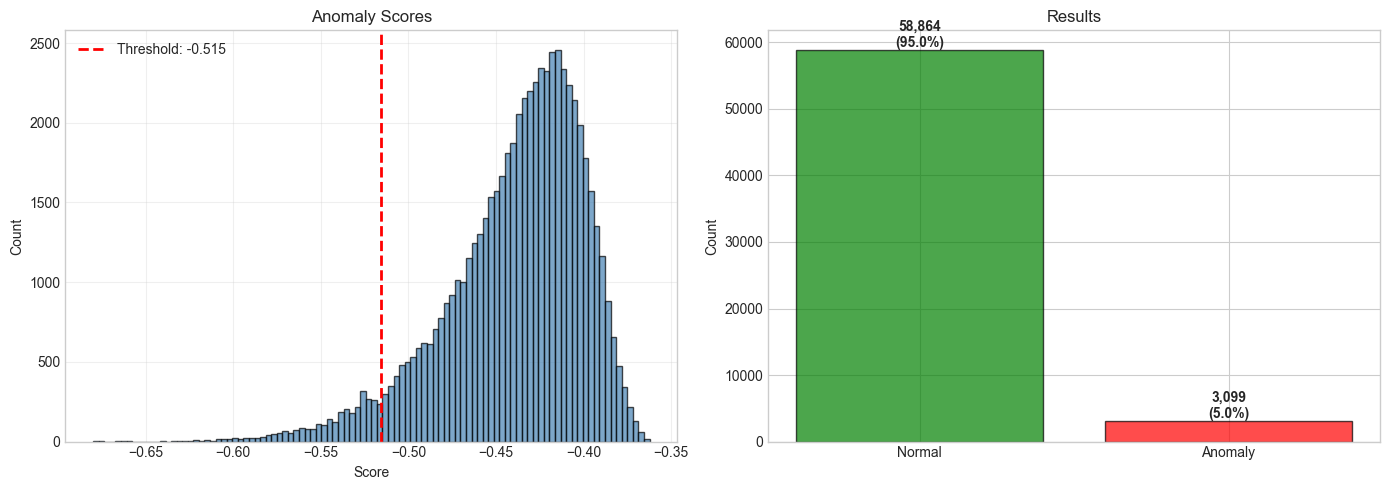

In [58]:
# Visualizing anomalies
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Anomaly score distribution
axes[0].hist(df.anomaly_score, bins=100, edgecolor='black', alpha=0.7, color='steelblue')

# threshold definition
threshold_normal_min = df[df.is_anomaly == 1].anomaly_score.min()
threshold_anomaly_max = df[df.is_anomaly == -1].anomaly_score.max()

threshold = threshold_normal_min  

# Plotting threshold line
axes[0].axvline(threshold, color='red', linestyle='--', linewidth=2, 
                label=f'Threshold: {threshold:.3f}')
axes[0].set(title='Anomaly Scores', xlabel='Score', ylabel='Count')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right plot: Bar chart
labels = ['Normal', 'Anomaly']
counts = [(df.is_anomaly == 1).sum(), (df.is_anomaly == -1).sum()]
axes[1].bar(labels, counts, color=['green', 'red'], edgecolor='black', alpha=0.7)
axes[1].set(title='Results', ylabel='Count')

for i, (label, count) in enumerate(zip(labels, counts)):
    pct = count / len(df) * 100
    axes[1].text(i, count, f'{count:,}\n({pct:.1f}%)', 
                ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [59]:
# Comparing anomalies
anomalies = df[df.is_anomaly == -1]
normal = df[df.is_anomaly == 1]

print('Comparison:')
for feat in ['price', 'minimum_nights', 'number_of_reviews']:
    if feat in df.columns:
        print(f'{feat}: Normal={normal[feat].median():.0f}, Anomaly={anomalies[feat].median():.0f}')

print(f'\nExamples:')
cols = ['price', 'minimum_nights', 'number_of_reviews']
cols = [c for c in cols if c in df.columns]
print(anomalies[cols].head())

Comparison:
price: Normal=132, Anomaly=248
minimum_nights: Normal=2, Anomaly=2
number_of_reviews: Normal=7, Anomaly=0

Examples:
     price  minimum_nights  number_of_reviews
117  150.0              90                189
158   57.0               1                  0
164  529.0               4                 28
253  781.0               1                  1
462   60.0               1                  0


In [60]:
# using rule based filtering to remove extreme outliers in price column
normal = df[df['is_anomaly'] == 1].copy()

df_clean = normal[
    (normal['price'] > 0) &  # Keep positive prices
    (normal['price'] <= 10000) &  # Remove > $10K
    ~((normal['price'] > 2000) & (normal['number_of_reviews'] == 0)) &  # Remove unvalidated high prices
    ((normal['price'] / normal['accommodates']) <= 1000)  # Remove unrealistic price-per-person
].copy()

print(f"Removed: {len(df) - len(df_clean):,} listings")
print(f"Keeing: {len(df_clean):,} listings")
print(f"Keeping high-price listings (>$1000): {(df_clean['price'] > 1000).sum()}")

Removed: 3,227 listings
Keeing: 58,736 listings
Keeping high-price listings (>$1000): 388


In [63]:
# Saving clean dataset

print(f'Original: {len(df):,}')
print(f'Clean: {len(df_clean):,}')
print(f'Removed: {len(df) - len(df_clean):,}')

df_clean.to_csv('data/processed/listings_clean.csv', index=False)
print('Saved clean data')

Original: 61,963
Clean: 58,736
Removed: 3,227
Saved clean data


Top 15 correlations:
accommodates                                   0.492004
bedrooms                                       0.462608
bathrooms                                      0.409991
beds                                           0.386297
estimated_revenue_l365d                        0.301086
calculated_host_listings_count_entire_homes    0.192665
calculated_host_listings_count                 0.154891
review_scores_location                         0.128298
host_total_listings_count                      0.082410
availability_30                                0.077392
review_scores_cleanliness                      0.067654
host_listings_count                            0.067368
availability_60                                0.066716
availability_365                               0.054831
review_scores_rating                           0.051266
Name: price, dtype: float64


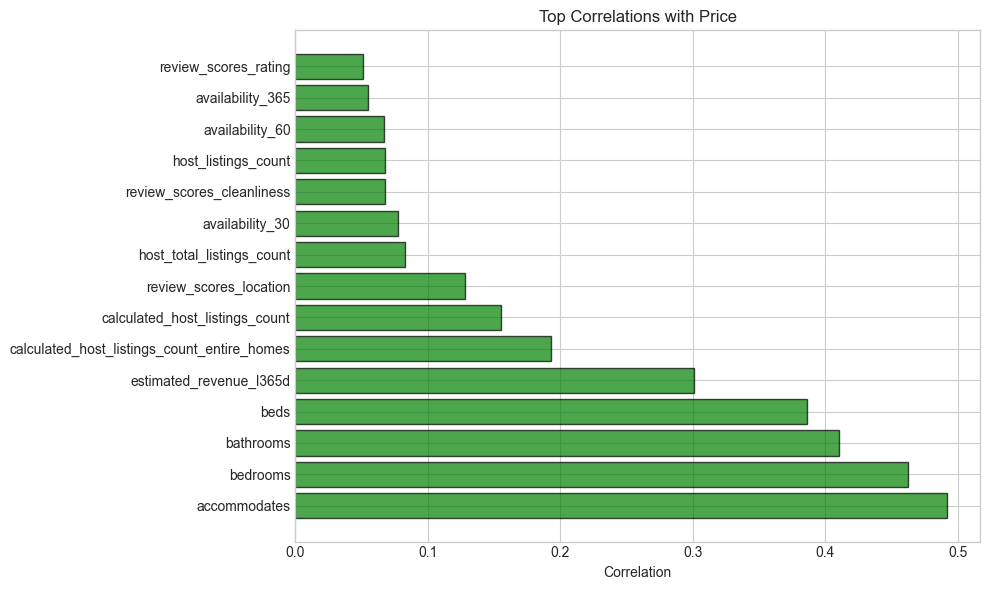

In [43]:
# Price correlations
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['id', 'host_id', 'scrape_id', 'is_anomaly']]

if 'price' in numeric_cols:
    corr = df_clean[numeric_cols].corr()['price'].sort_values(ascending=False)
    corr = corr[corr.index != 'price'].head(15)
    print('Top 15 correlations:')
    print(corr)
    
    plt.figure(figsize=(10, 6))
    colors = ['green' if x > 0 else 'red' for x in corr.values]
    plt.barh(range(len(corr)), corr.values, color=colors, edgecolor='black', alpha=0.7)
    plt.yticks(range(len(corr)), corr.index)
    plt.xlabel('Correlation')
    plt.title('Top Correlations with Price')
    plt.tight_layout()
    plt.show()

In [45]:
print('EDA Summary')
print(f'Clean dataset: {len(df_clean):,} listings')
print(f'Median price: ${df_clean.price.median():.0f}')
print(f'Anomalies removed: {len(df) - len(df_clean):,}')
print('\nNext: Feature engineering')

EDA Summary
Clean dataset: 58,736 listings
Median price: $132
Anomalies removed: 3,227

Next: Feature engineering
